Connected to shocks (Python 3.10.18)

In [ ]:
import sys
sys.path.append('/Users/paolamartire/shocks/')

import numpy as np
import agama
import healpy as hp
import matplotlib.pyplot as plt
from Utilities import prelude as prel 
from Utilities import operators as op
import astropy.units as u

# ----------------------------
#%% Physical / numerical setup
# ----------------------------
G = prel.G  
M = 1e4
Rt = 13
conversion_sol_kms = prel.Rsol_cgs*1e-5/prel.tsol_cgs
conversion_tfb_tsol = (2.5*24*3600)/prel.tsol_cgs

agama.setUnits(length = (prel.Rsol_cgs)*u.cm.to(u.kpc), velocity=conversion_sol_kms*u.km/u.s, mass=1.0)  
# current_units = agama.getUnits()
# Point-mass-like potential at the origin
pot = agama.Potential(type='Plummer', mass=M, scaleRadius=1e-6)

# Source initial conditions
r_source0 = np.array([9, 0.0, 0.0])
v_source0  = np.array([-2, -45, -2])

In [ ]:
vel_radial_centre, _, _ = op.to_spherical_components(v_source0[0], v_source0[1], v_source0[2], r_source0[0], r_source0[1], r_source0[2])
v_launch = 20
n_batches = 100      # number of launch times
NSIDE = prel.NSIDE          # Healpix resolution parameter, which determines the number of directions to launch particles

In [ ]:
t_end = int(2.5 * conversion_tfb_tsol)  # 2.5 tfb in code units
dt_launch = t_end / n_batches
trajsize = 1000
times = np.linspace(0.0, t_end, trajsize)

def OrbitalEnergy(potential, position, velocity):
    kinetic_energy = 0.5 * np.linalg.norm(velocity)**2
    potential_energy = potential.potential(position)
    return kinetic_energy + potential_energy

def source_state(t, v_source):
    v = v_source.copy()
    r = r_source0 + v_source * t
    return r, v

def velocity_vectors(nside, speed):
    npix = hp.nside2npix(nside)
    observers_xyz = hp.pix2vec(nside, range(npix))
    observers_xyz = np.array(observers_xyz)
    return observers_xyz.T * speed

def integrate_one_particle(r0, v0, t0, t_end, trajsize):
    ic = np.hstack((r0, v0))
    # Agama orbit integrates forward from the given initial condition
    # If you want a particle launched at t0, we integrate the state from that moment onward.
    tt = np.linspace(t0, t_end, trajsize)
    traj = agama.orbit(potential=pot, ic=ic, time=t_end - t0, trajsize=trajsize)[1]
    return tt, traj

# ----------------------------
# Launch particles
# ----------------------------
cut_in_oe = False
all_launch_times = []
all_trajectories = []
tt_orbits = []
source_trajectories = []
orb_energies = []

tt_s, traj_s = integrate_one_particle(r_source0, v_source0, 0, t_end, trajsize)
rsrc, vsrc = traj_s[:, :3], traj_s[:, 3:]
# rsrc = np.array(len(tt_s) * [[13,0,0]])
# vsrc = np.zeros((len(tt_s), 3)) 

In [ ]:
for k, t0 in enumerate(tt_s[:-1:100]):
# for k in range(n_batches):
    # t0 = k * dt_launch
    # rsrc, vsrc = source_state(t0, v_source0)
    # source_trajectories.append(rsrc)

    directions = velocity_vectors(NSIDE, v_launch)

    r0 = rsrc[k].copy()
    v0l = vsrc[k] + directions
    # v0l = vsrc + directions
    for i in range(len(v0l)):
        r0 = rsrc.copy()
        v0 = v0l[i].copy()
        orb_en = OrbitalEnergy(pot, r0, v0)
        if cut_in_oe:
            if orb_en < 0:
                # print('Delete particle')
                continue
        tt, traj = integrate_one_particle(r0, v0, t0, t_end, trajsize)
        all_launch_times.append(t0)
        all_trajectories.append(traj)
        tt_orbits.append(tt)
        orb_en = OrbitalEnergy(pot, traj[:, :3], traj[:, 3:])
        orb_energies.append(orb_en)

source_trajectories = np.array(source_trajectories)
all_launch_times = np.array(all_launch_times)
all_trajectories = np.array(all_trajectories)
orb_energies = np.array(orb_energies)
tt_orbits = np.array(tt_orbits)

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [ ]:
print("Number of launched particles:", len(all_trajectories))
print("Number of dts:", n_batches)
print("Shape of all trajectories array:", all_trajectories.shape)
print("First trajectory shape:", all_trajectories[0].shape)

: 

In [ ]:
wanted_times = [all_launch_times[0], all_launch_times[len(all_launch_times)//2], all_launch_times[-1]]  # first, middle, last launch times
plt.figure(figsize=(8, 6)) 
# plt.scatter(source_trajectories[:,0]/Rt, source_trajectories[:,1]/Rt, c = 'k', s = 10, label='Source')
plt.scatter(rsrc[:,0]/Rt, rsrc[:,1]/Rt, c = 'k', s = 10, label='Source')
colors_plot = ['seagreen', 'royalblue', 'goldenrod', 'lightcoral', 'crimson']
# iii = [10, 20]
for i, wanted_time in enumerate(wanted_times):
    idx_wanted_time = np.where(all_launch_times == wanted_time)[0] # each of them corresponds to a different particle launched at the same time
    if len(idx_wanted_time) != 192:
        print('something is wrong')
    x_traj = all_trajectories[idx_wanted_time, :, 0]
    y_traj = all_trajectories[idx_wanted_time, :, 1]
    velR, _, _ = op.to_spherical_components(all_trajectories[idx_wanted_time, :, 3], all_trajectories[idx_wanted_time, :, 4], all_trajectories[idx_wanted_time, :, 5], all_trajectories[idx_wanted_time, :, 0], all_trajectories[idx_wanted_time, :, 1], all_trajectories[idx_wanted_time, :, 2])
    x_traj = x_traj[velR > 0]
    y_traj = y_traj[velR > 0]
    plt.plot(x_traj/Rt, y_traj/Rt, c = colors_plot[i], alpha=0.5)
    plt.plot(x_traj[0]/Rt, y_traj[0]/Rt, c = colors_plot[i], alpha=0.5, label=f't = {wanted_time:.0f} c.u. particles') # just for the label
    # else:
    #     plt.scatter(all_trajectories[idx_wanted_time, :, 0], all_trajectories[idx_wanted_time, :, 1], c = orb_energies[idx_wanted_time, :].T, s = 1, cmap = 'coolwarm', vmin = -10, vmax = 10)

plt.xlabel('X')
plt.ylabel('Y')
# plt.xlim(-25, 25)
# plt.ylim(-25, 25)
plt.legend()

: 

In [ ]:
velR_last, _, _ = op.to_spherical_components(all_trajectories[:, -1, 3], all_trajectories[:, -1, 4], all_trajectories[:, -1, 5], all_trajectories[:, -1, 0], all_trajectories[:, -1, 1], all_trajectories[:, -1, 2])
r_last = np.linalg.norm(all_trajectories[:, -1, :3], axis=1)
cut_pos = np.logical_and(all_trajectories[:, -1, 0] > 0, velR_last > 0)
cut_neg = np.logical_and(all_trajectories[:, -1, 0] < 0, velR_last > 0)
r_last_pos = r_last[cut_pos]/Rt
r_last_neg = r_last[cut_neg]/Rt
velR_last_pos = velR_last[cut_pos] 
velR_last_neg = velR_last[cut_neg] 
x_positive = len(r_last_pos)
x_negative = len(r_last_neg)
print(f"Number of particles with x > 0 at {tt[-1]}: {x_positive}")
print(f"Number of particles with x < 0 at {tt[-1]}: {x_negative}")

countRpos, bin_edges = np.histogram(r_last_pos, bins=20)
countRneg, bin_edges = np.histogram(r_last_neg, bins=20)
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], countRpos, width=np.diff(bin_edges), label='x > 0', color='dodgerblue')
plt.bar(bin_edges[:-1], countRneg, width=np.diff(bin_edges), alpha=0.5, label='x < 0', color='lightcoral')
plt.xlabel('Radial distance r (Rt)')
plt.ylabel('Number of particles')
plt.legend()
plt.loglog()
plt.title(f'Particle distribution at t = {tt[-1]}')

Nvr_pos = np.zeros_like(bin_edges[:-1])
Nvr_neg = np.zeros_like(bin_edges[:-1])
for i, r in enumerate(bin_edges[:-1]):
    # check where Rpos is between r and r+bins_r
    cut_count_pos = (r_last_pos >= r) & (r_last_pos < bin_edges[i+1])
    cut_count_neg = (r_last_neg >= r) & (r_last_neg < bin_edges[i+1])
    Nvr_pos[i] = len(r_last_pos[cut_count_pos])* np.mean(velR_last_pos[cut_count_pos]) if len(r_last_pos[cut_count_pos]) > 0 else 0
    Nvr_neg[i] = len(r_last_neg[cut_count_neg])* np.mean(velR_last_neg[cut_count_neg]) if len(r_last_neg[cut_count_neg]) > 0 else 0

plt.figure(figsize=(7,5))
plt.plot(bin_edges[:-1], Nvr_pos, '-o', label='Positive x', color='dodgerblue')
plt.plot(bin_edges[:-1], Nvr_neg, '-o', label='Negative x', color='lightcoral')
plt.xlabel('r')
plt.ylabel(r'dN/dr $\langle v_r \rangle$')
plt.loglog()
plt.legend()

: 

In [ ]:
from Utilities.operators import sort_list
countvRpos, bin_edges = np.histogram(velR_last_pos * conversion_sol_kms, bins=20)
countvRneg, bin_edges = np.histogram(velR_last_neg * conversion_sol_kms, bins=20)
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], countvRpos, width=np.diff(bin_edges), label='x > 0', color='dodgerblue')
plt.bar(bin_edges[:-1], countvRneg, width=np.diff(bin_edges), alpha=0.5, label='x < 0', color='lightcoral')
plt.xlabel('Radial velocity (km/s)')
plt.ylabel('Count of particles')
plt.legend()
plt.loglog()
plt.title(f'Particle distribution at t = {tt[-1]}')

plt.figure(figsize=(8, 6))
velR_last_pos, r_last_pos= sort_list([velR_last_pos, r_last_pos], r_last_pos)
velR_last_neg, r_last_neg= sort_list([velR_last_neg, r_last_neg], r_last_neg)
plt.scatter(r_last_pos, velR_last_pos * conversion_sol_kms, label='x > 0', color='dodgerblue')
plt.scatter(r_last_neg, velR_last_neg * conversion_sol_kms, label='x < 0', color='lightcoral', alpha=0.5)
plt.xlabel('Radial distance r (Rt)')
plt.ylabel('Radial velocity (km/s)')
plt.loglog()
plt.legend()
# plt.xlim(1e2, 2e3)

: 

In [ ]:
import sys
sys.path.append('/Users/paolamartire/shocks/')

import numpy as np
import agama
import healpy as hp
import matplotlib.pyplot as plt
from Utilities import prelude as prel 
from Utilities import operators as op
import astropy.units as u

# ----------------------------
#%% Physical / numerical setup
# ----------------------------
G = prel.G  
M = 1e4
Rt = 13
conversion_sol_kms = prel.Rsol_cgs*1e-5/prel.tsol_cgs
conversion_tfb_tsol = (2.5*24*3600)/prel.tsol_cgs

agama.setUnits(length = (prel.Rsol_cgs)*u.cm.to(u.kpc), velocity=conversion_sol_kms*u.km/u.s, mass=1.0)  
# current_units = agama.getUnits()
# Point-mass-like potential at the origin
pot = agama.Potential(type='Plummer', mass=M, scaleRadius=1e-6)

# Source initial conditions
r_source0 = np.array([9, 0.0, 0.0])
v_source0  = np.array([-2, -45, -2])

In [ ]:
vel_radial_centre, _, _ = op.to_spherical_components(v_source0[0], v_source0[1], v_source0[2], r_source0[0], r_source0[1], r_source0[2])
v_launch = 20
n_batches = 100      # number of launch times
NSIDE = prel.NSIDE          # Healpix resolution parameter, which determines the number of directions to launch particles

In [ ]:
t_end = int(2.5 * conversion_tfb_tsol)  # 2.5 tfb in code units
dt_launch = t_end / n_batches
trajsize = 1000
times = np.linspace(0.0, t_end, trajsize)

def OrbitalEnergy(potential, position, velocity):
    kinetic_energy = 0.5 * np.linalg.norm(velocity)**2
    potential_energy = potential.potential(position)
    return kinetic_energy + potential_energy

def source_state(t, v_source):
    v = v_source.copy()
    r = r_source0 + v_source * t
    return r, v

def velocity_vectors(nside, speed):
    npix = hp.nside2npix(nside)
    observers_xyz = hp.pix2vec(nside, range(npix))
    observers_xyz = np.array(observers_xyz)
    return observers_xyz.T * speed

def integrate_one_particle(r0, v0, t0, t_end, trajsize):
    ic = np.hstack((r0, v0))
    # Agama orbit integrates forward from the given initial condition
    # If you want a particle launched at t0, we integrate the state from that moment onward.
    tt = np.linspace(t0, t_end, trajsize)
    traj = agama.orbit(potential=pot, ic=ic, time=t_end - t0, trajsize=trajsize)[1]
    return tt, traj

# ----------------------------
# Launch particles
# ----------------------------
cut_in_oe = False
all_launch_times = []
all_trajectories = []
tt_orbits = []
source_trajectories = []
orb_energies = []

tt_s, traj_s = integrate_one_particle(r_source0, v_source0, 0, t_end, trajsize)
rsrc, vsrc = traj_s[:, :3], traj_s[:, 3:]
# rsrc = np.array(len(tt_s) * [[13,0,0]])
# vsrc = np.zeros((len(tt_s), 3)) 

In [ ]:
for k, t0 in enumerate(tt_s[:-1:100]):
# for k in range(n_batches):
    # t0 = k * dt_launch
    # rsrc, vsrc = source_state(t0, v_source0)
    # source_trajectories.append(rsrc)

    directions = velocity_vectors(NSIDE, v_launch)

    r0 = rsrc[k].copy()
    v0l = vsrc[k] + directions
    # v0l = vsrc + directions
    for i in range(len(v0l)):
        # r0 = rsrc.copy()
        v0 = v0l[i].copy()
        orb_en = OrbitalEnergy(pot, r0, v0)
        if cut_in_oe:
            if orb_en < 0:
                # print('Delete particle')
                continue
        tt, traj = integrate_one_particle(r0, v0, t0, t_end, trajsize)
        all_launch_times.append(t0)
        all_trajectories.append(traj)
        tt_orbits.append(tt)
        orb_en = OrbitalEnergy(pot, traj[:, :3], traj[:, 3:])
        orb_energies.append(orb_en)

source_trajectories = np.array(source_trajectories)
all_launch_times = np.array(all_launch_times)
all_trajectories = np.array(all_trajectories)
orb_energies = np.array(orb_energies)
tt_orbits = np.array(tt_orbits)

In [ ]:
print("Number of launched particles:", len(all_trajectories))
print("Number of dts:", n_batches)
print("Shape of all trajectories array:", all_trajectories.shape)
print("First trajectory shape:", all_trajectories[0].shape)

Number of launched particles: 1920
Number of dts: 100
Shape of all trajectories array: (1920, 1000, 6)
First trajectory shape: (1000, 6)


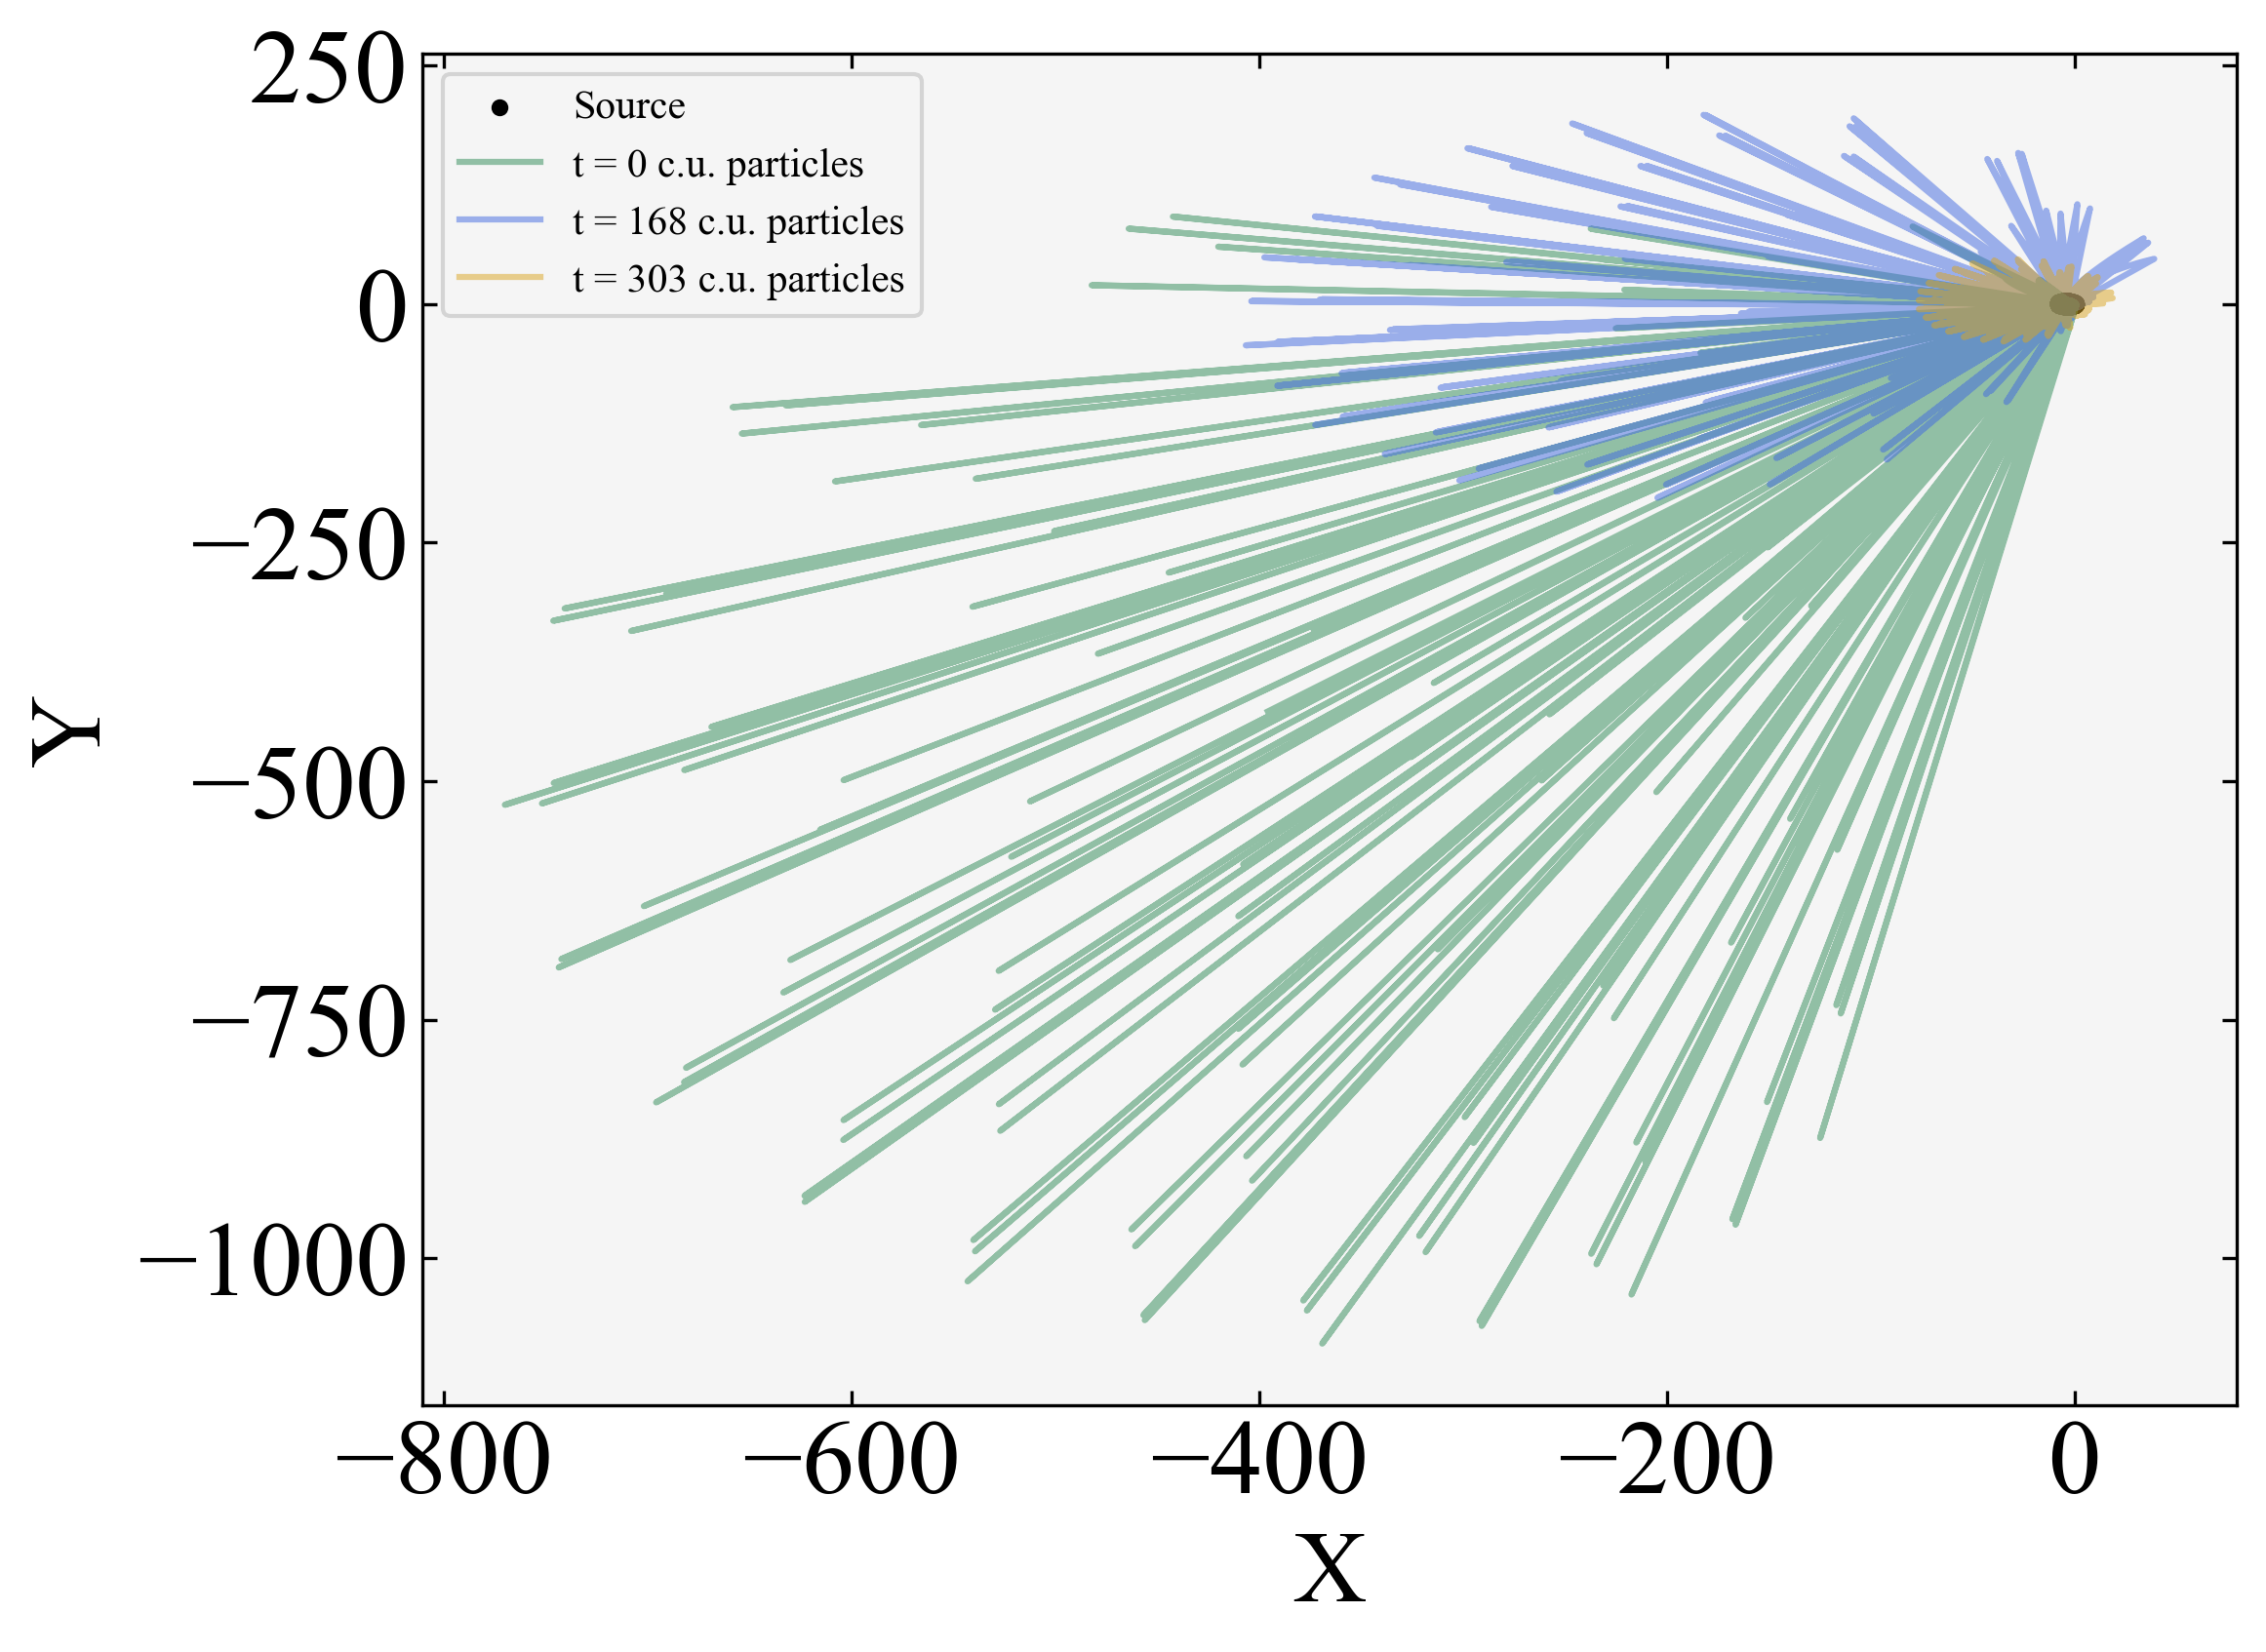

In [ ]:
wanted_times = [all_launch_times[0], all_launch_times[len(all_launch_times)//2], all_launch_times[-1]]  # first, middle, last launch times
plt.figure(figsize=(8, 6)) 
# plt.scatter(source_trajectories[:,0]/Rt, source_trajectories[:,1]/Rt, c = 'k', s = 10, label='Source')
plt.scatter(rsrc[:,0]/Rt, rsrc[:,1]/Rt, c = 'k', s = 10, label='Source')
colors_plot = ['seagreen', 'royalblue', 'goldenrod', 'lightcoral', 'crimson']
# iii = [10, 20]
for i, wanted_time in enumerate(wanted_times):
    idx_wanted_time = np.where(all_launch_times == wanted_time)[0] # each of them corresponds to a different particle launched at the same time
    if len(idx_wanted_time) != 192:
        print('something is wrong')
    x_traj = all_trajectories[idx_wanted_time, :, 0]
    y_traj = all_trajectories[idx_wanted_time, :, 1]
    velR, _, _ = op.to_spherical_components(all_trajectories[idx_wanted_time, :, 3], all_trajectories[idx_wanted_time, :, 4], all_trajectories[idx_wanted_time, :, 5], all_trajectories[idx_wanted_time, :, 0], all_trajectories[idx_wanted_time, :, 1], all_trajectories[idx_wanted_time, :, 2])
    x_traj = x_traj[velR > 0]
    y_traj = y_traj[velR > 0]
    plt.plot(x_traj/Rt, y_traj/Rt, c = colors_plot[i], alpha=0.5)
    plt.plot(x_traj[0]/Rt, y_traj[0]/Rt, c = colors_plot[i], alpha=0.5, label=f't = {wanted_time:.0f} c.u. particles') # just for the label
    # else:
    #     plt.scatter(all_trajectories[idx_wanted_time, :, 0], all_trajectories[idx_wanted_time, :, 1], c = orb_energies[idx_wanted_time, :].T, s = 1, cmap = 'coolwarm', vmin = -10, vmax = 10)

plt.xlabel('X')
plt.ylabel('Y')
# plt.xlim(-25, 25)
# plt.ylim(-25, 25)
plt.legend()

Number of particles with x > 0 at 336.0: 179
Number of particles with x < 0 at 336.0: 1403


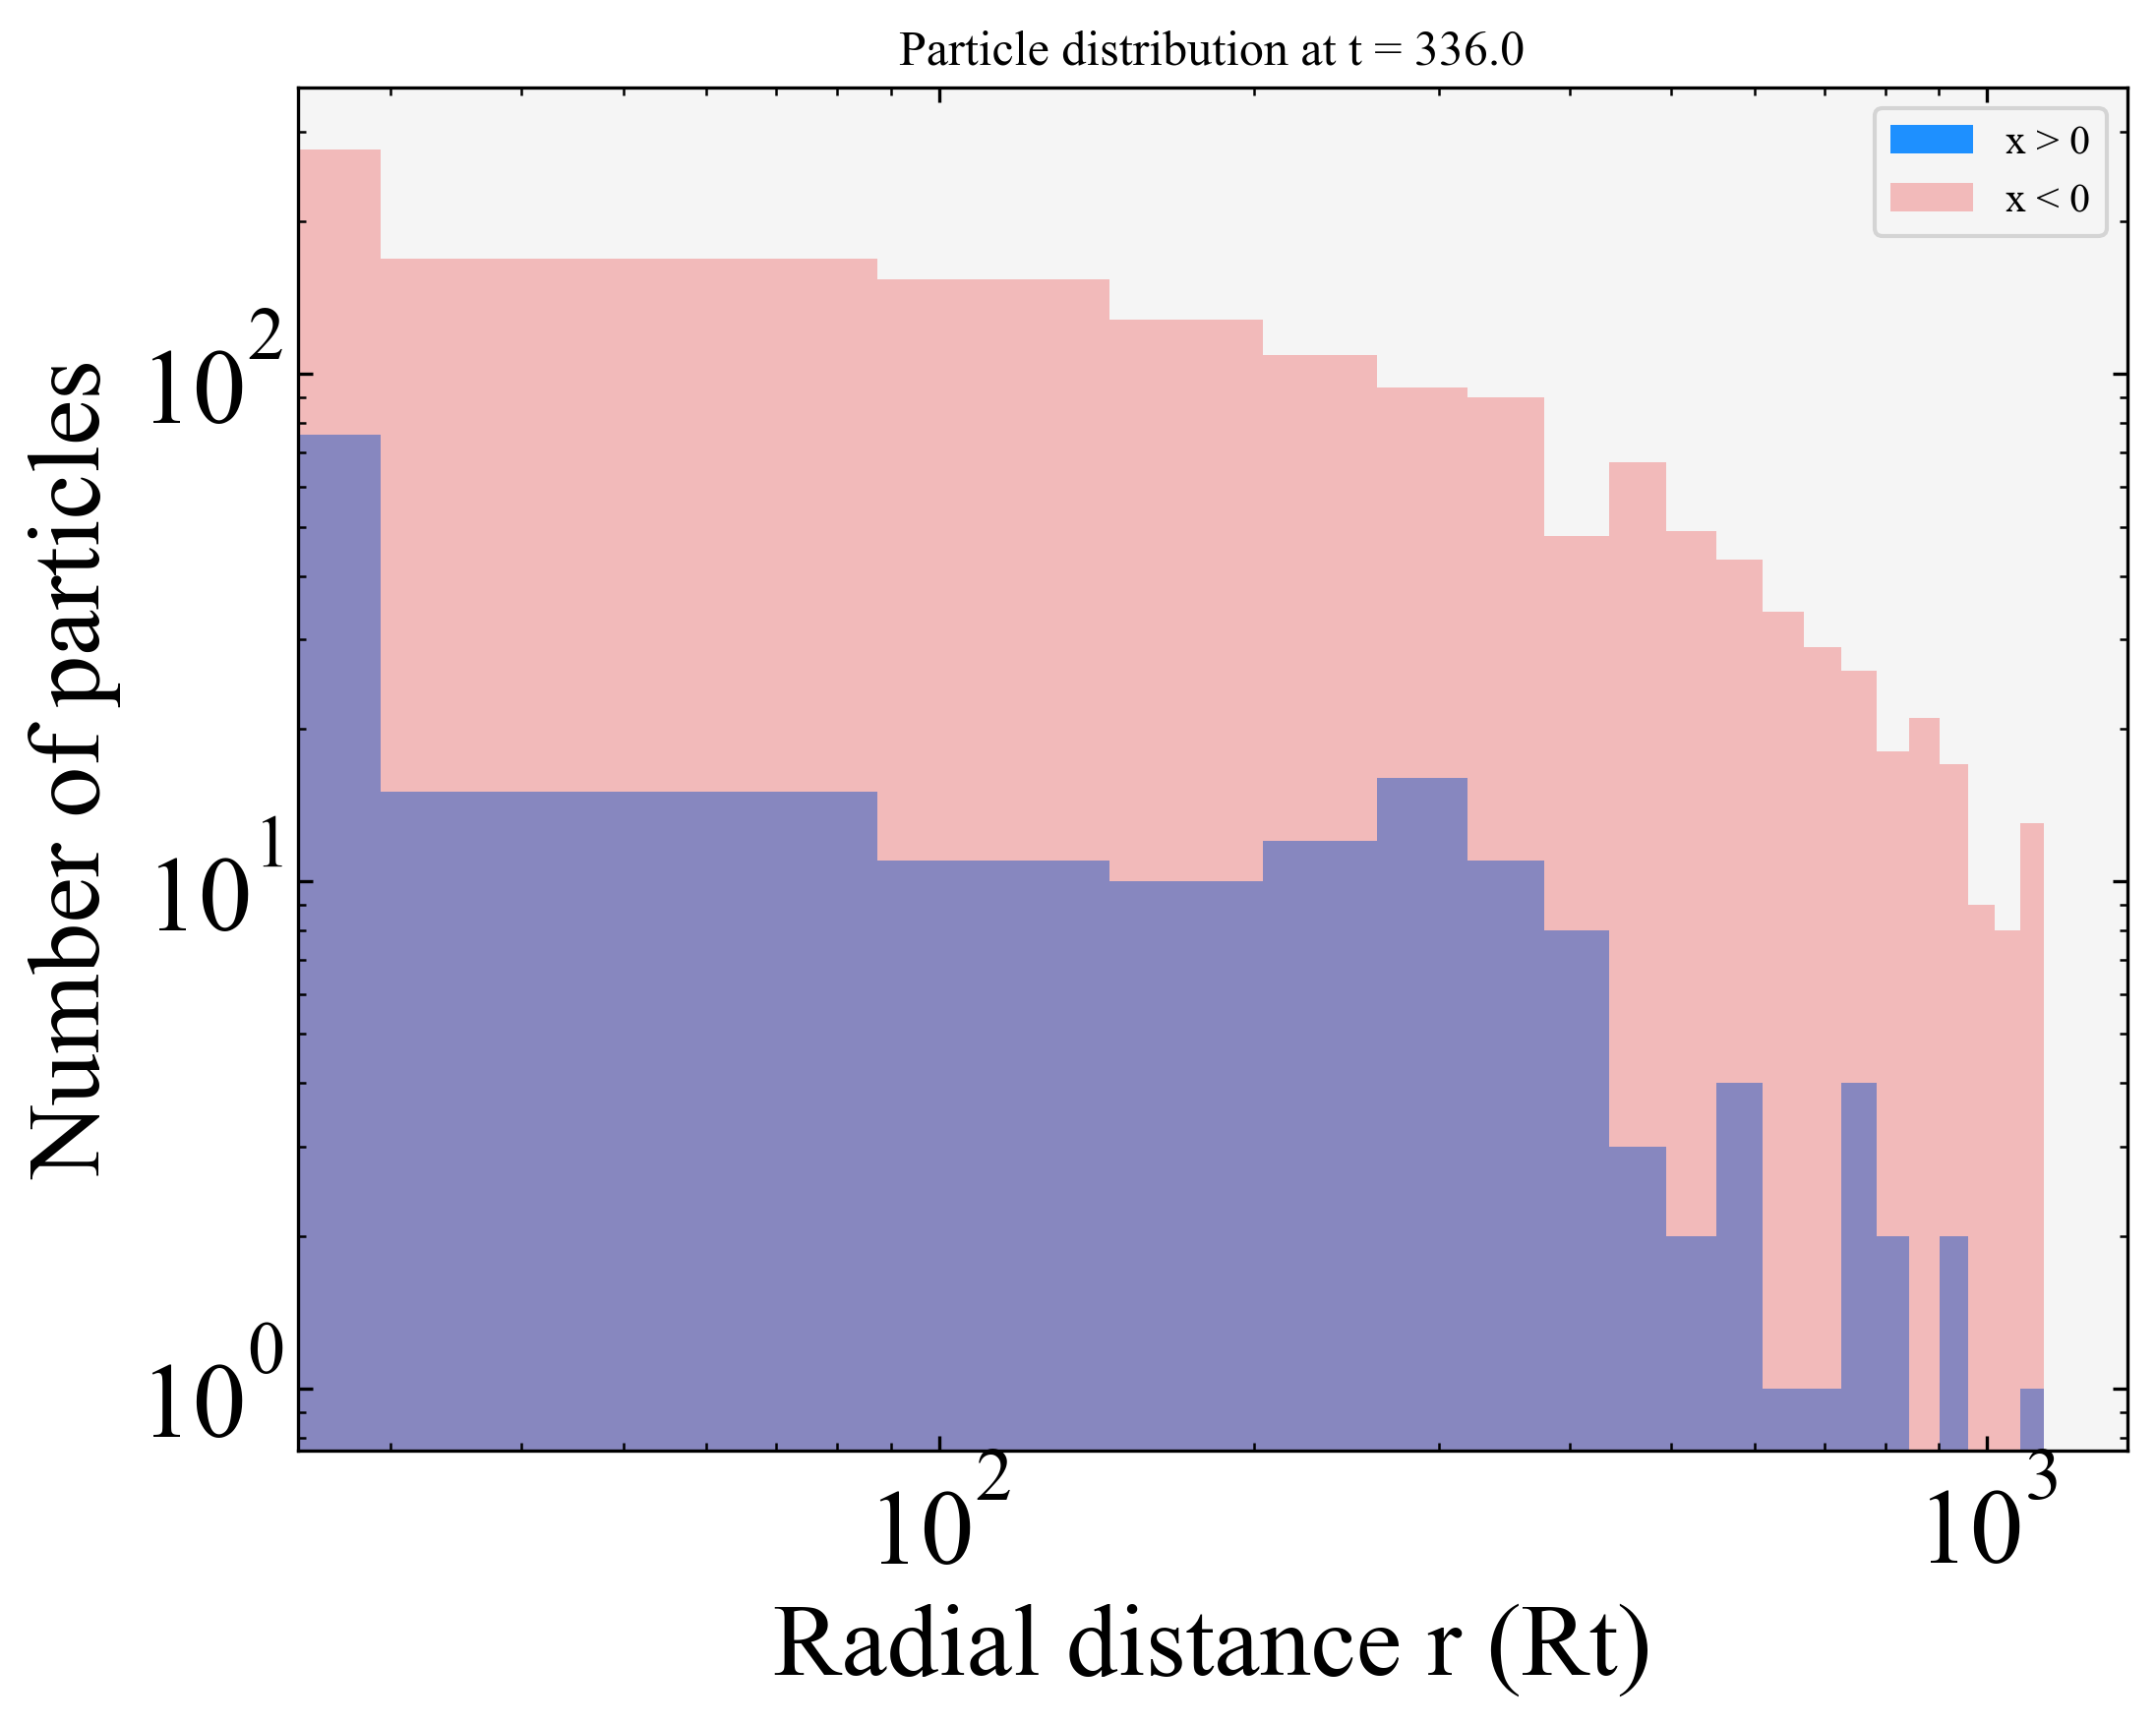

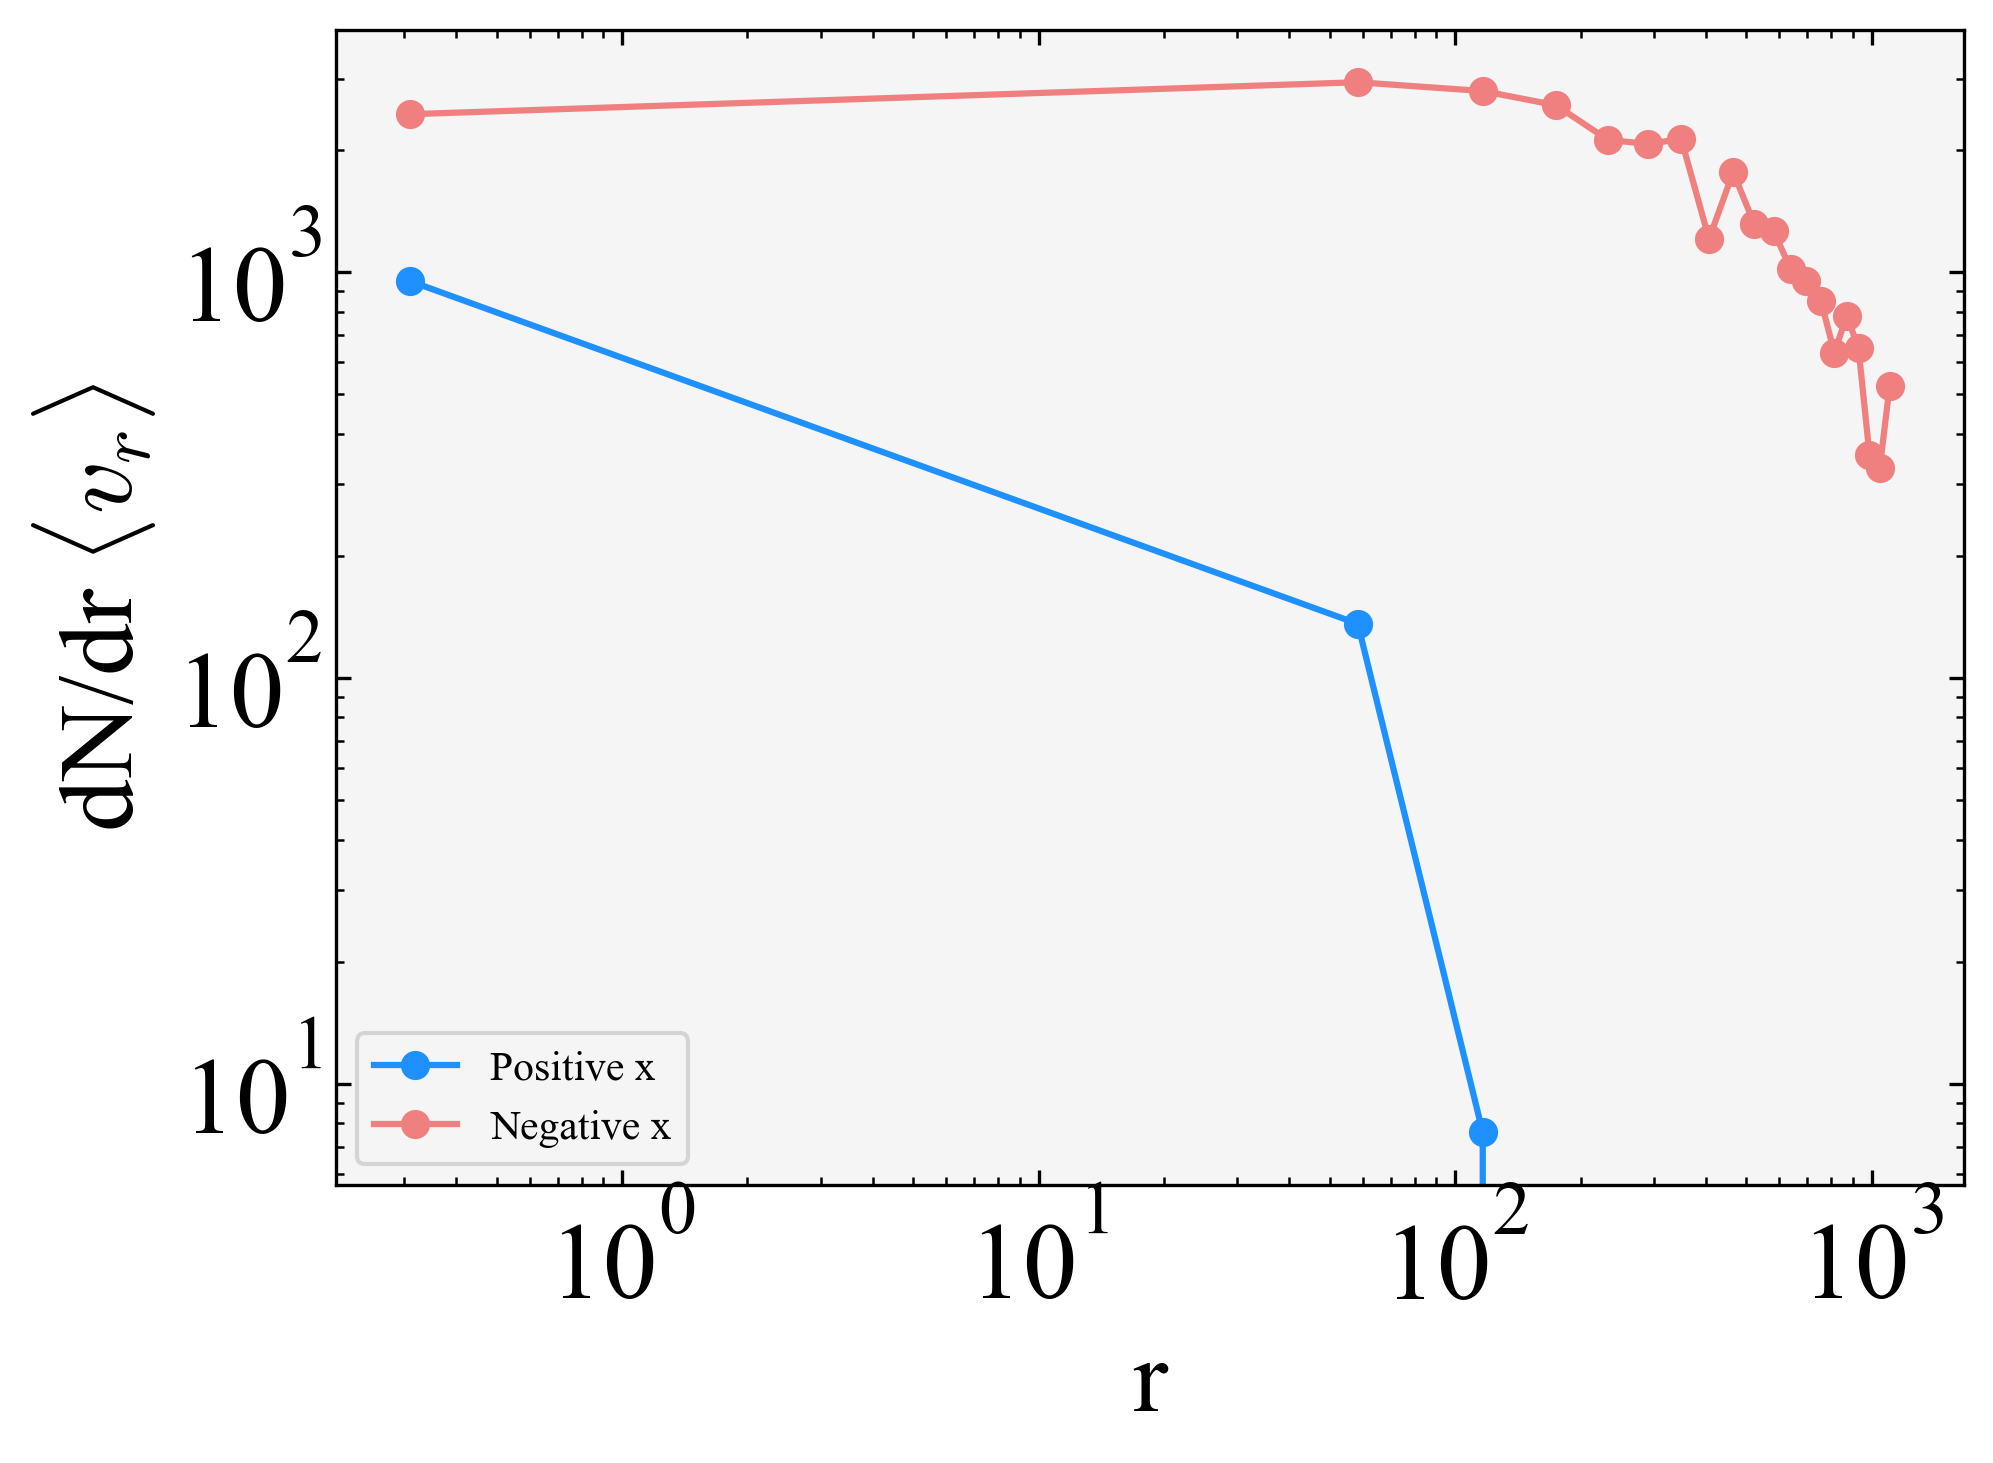

In [ ]:
velR_last, _, _ = op.to_spherical_components(all_trajectories[:, -1, 3], all_trajectories[:, -1, 4], all_trajectories[:, -1, 5], all_trajectories[:, -1, 0], all_trajectories[:, -1, 1], all_trajectories[:, -1, 2])
r_last = np.linalg.norm(all_trajectories[:, -1, :3], axis=1)
cut_pos = np.logical_and(all_trajectories[:, -1, 0] > 0, velR_last > 0)
cut_neg = np.logical_and(all_trajectories[:, -1, 0] < 0, velR_last > 0)
r_last_pos = r_last[cut_pos]/Rt
r_last_neg = r_last[cut_neg]/Rt
velR_last_pos = velR_last[cut_pos] 
velR_last_neg = velR_last[cut_neg] 
x_positive = len(r_last_pos)
x_negative = len(r_last_neg)
print(f"Number of particles with x > 0 at {tt[-1]}: {x_positive}")
print(f"Number of particles with x < 0 at {tt[-1]}: {x_negative}")

countRpos, bin_edges = np.histogram(r_last_pos, bins=20)
countRneg, bin_edges = np.histogram(r_last_neg, bins=20)
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], countRpos, width=np.diff(bin_edges), label='x > 0', color='dodgerblue')
plt.bar(bin_edges[:-1], countRneg, width=np.diff(bin_edges), alpha=0.5, label='x < 0', color='lightcoral')
plt.xlabel('Radial distance r (Rt)')
plt.ylabel('Number of particles')
plt.legend()
plt.loglog()
plt.title(f'Particle distribution at t = {tt[-1]}')

Nvr_pos = np.zeros_like(bin_edges[:-1])
Nvr_neg = np.zeros_like(bin_edges[:-1])
for i, r in enumerate(bin_edges[:-1]):
    # check where Rpos is between r and r+bins_r
    cut_count_pos = (r_last_pos >= r) & (r_last_pos < bin_edges[i+1])
    cut_count_neg = (r_last_neg >= r) & (r_last_neg < bin_edges[i+1])
    Nvr_pos[i] = len(r_last_pos[cut_count_pos])* np.mean(velR_last_pos[cut_count_pos]) if len(r_last_pos[cut_count_pos]) > 0 else 0
    Nvr_neg[i] = len(r_last_neg[cut_count_neg])* np.mean(velR_last_neg[cut_count_neg]) if len(r_last_neg[cut_count_neg]) > 0 else 0

plt.figure(figsize=(7,5))
plt.plot(bin_edges[:-1], Nvr_pos, '-o', label='Positive x', color='dodgerblue')
plt.plot(bin_edges[:-1], Nvr_neg, '-o', label='Negative x', color='lightcoral')
plt.xlabel('r')
plt.ylabel(r'dN/dr $\langle v_r \rangle$')
plt.loglog()
plt.legend()

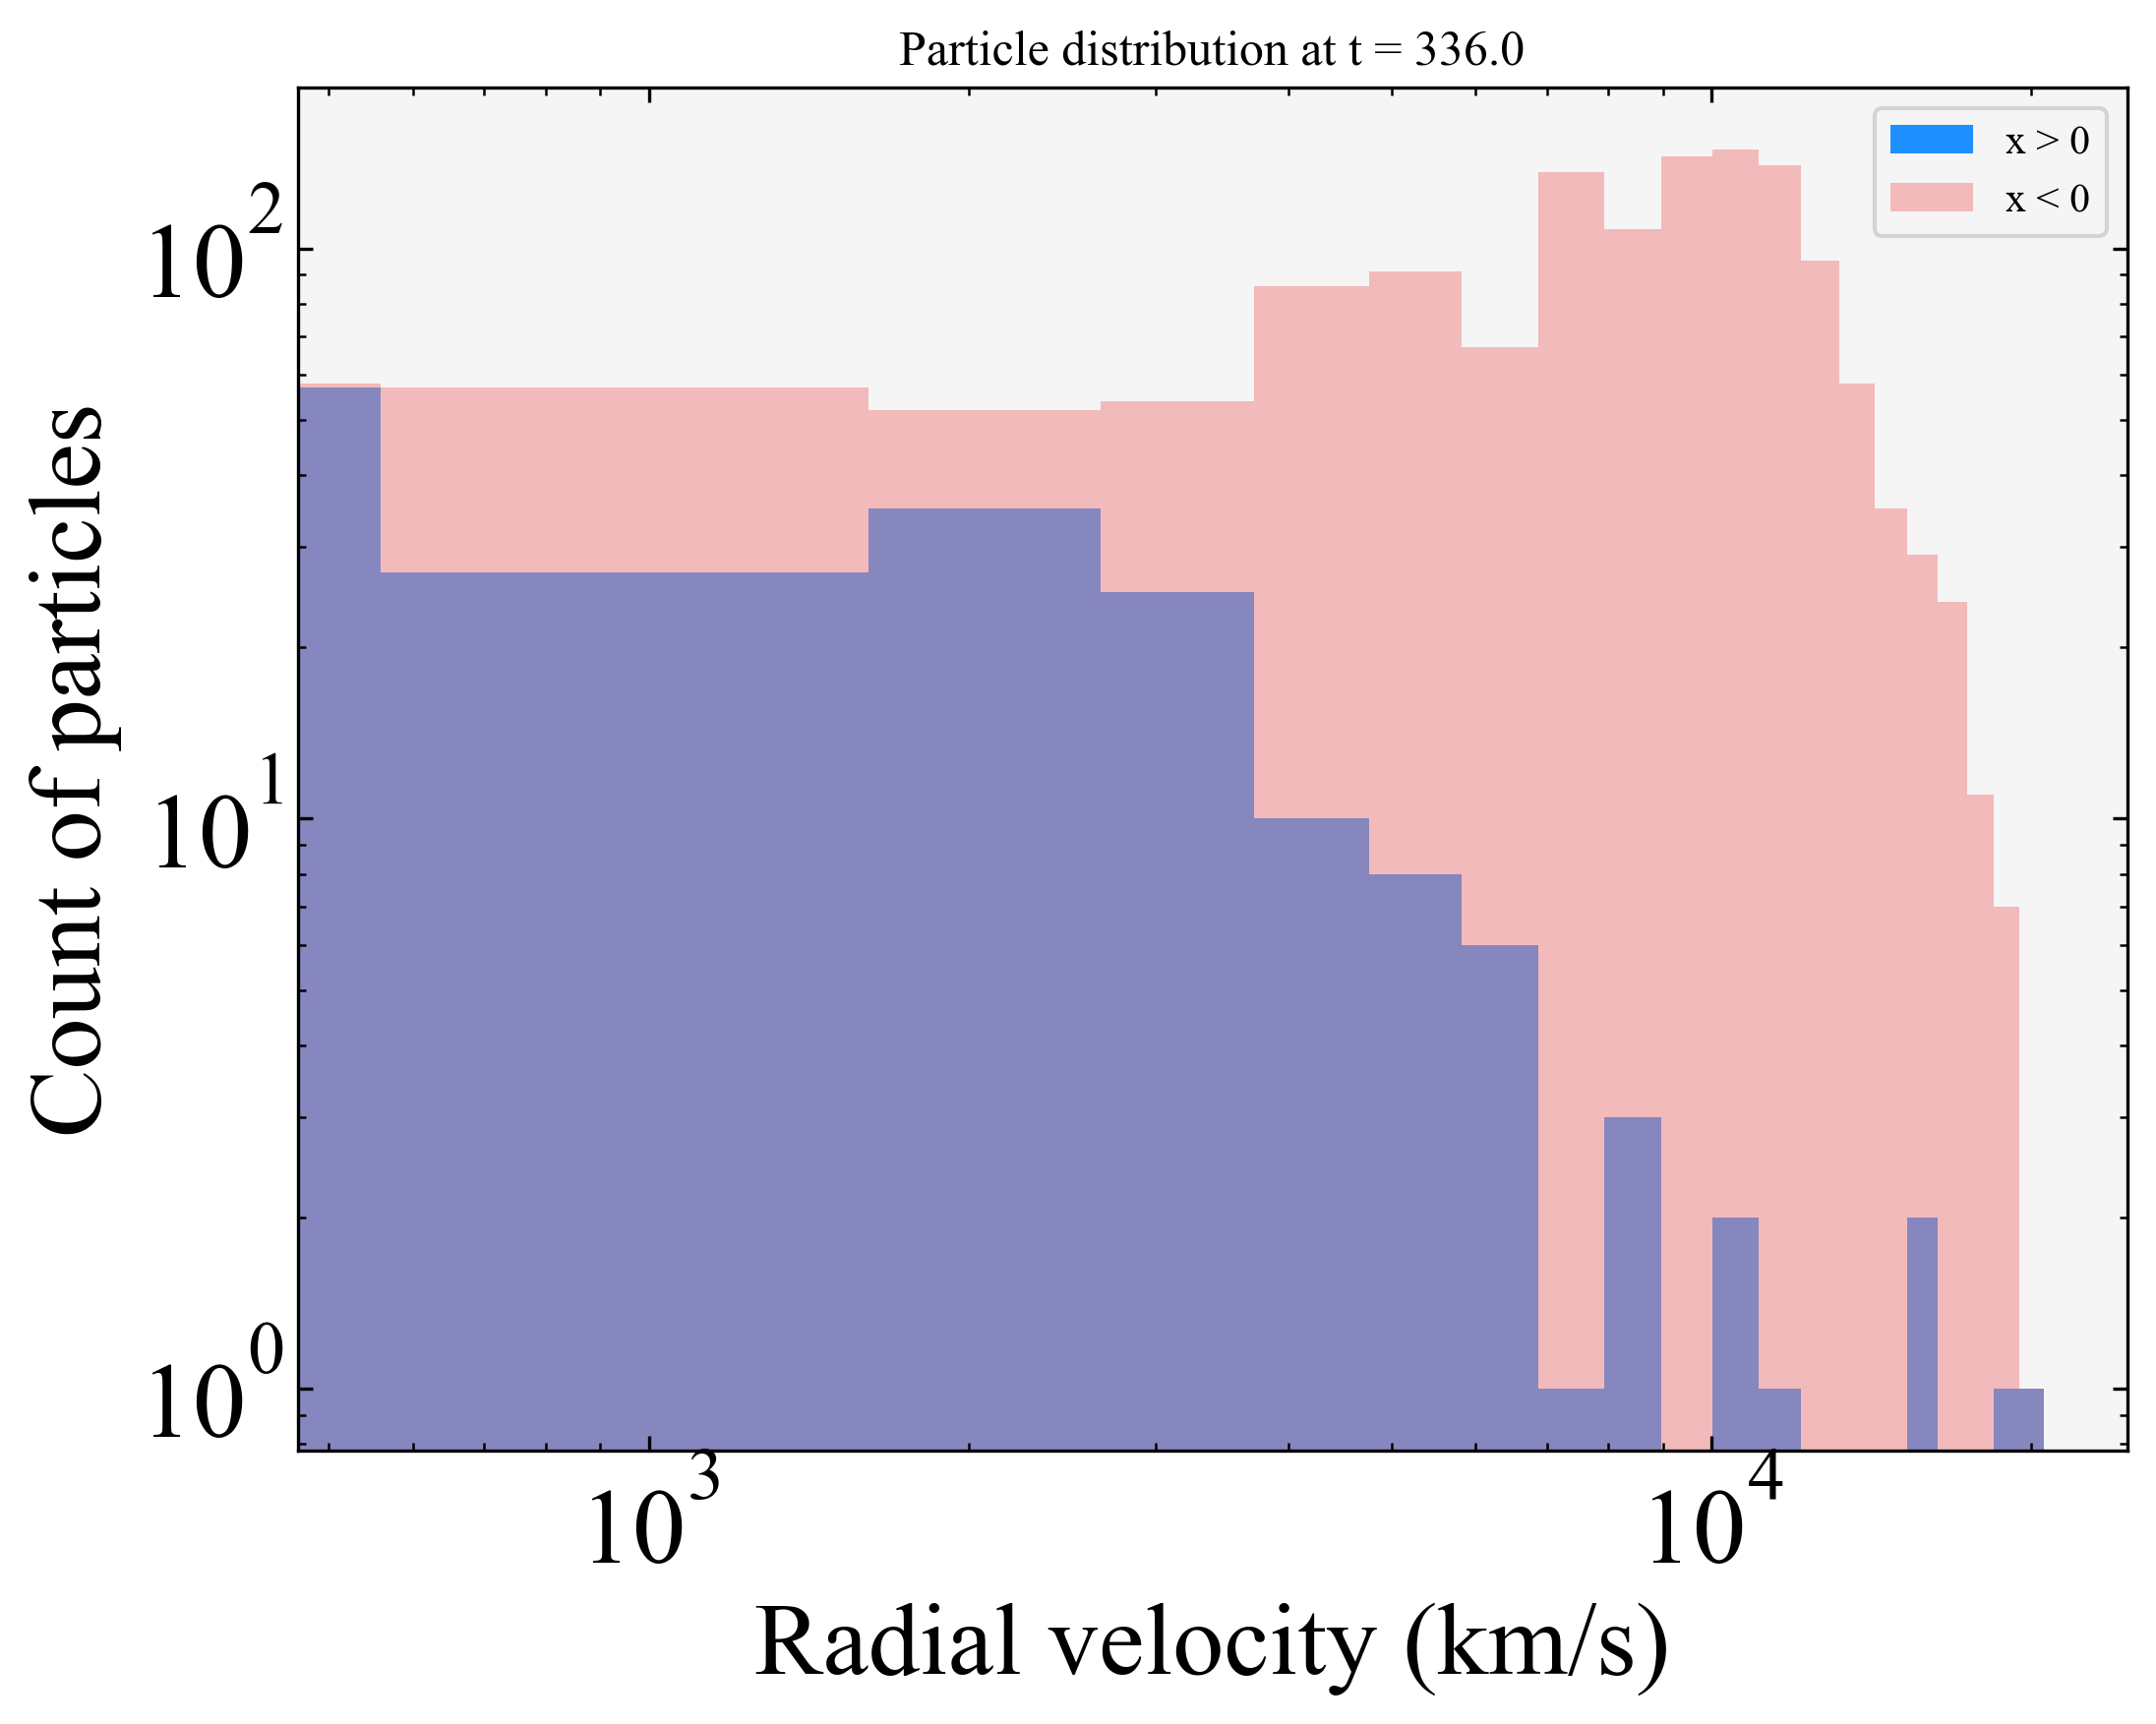

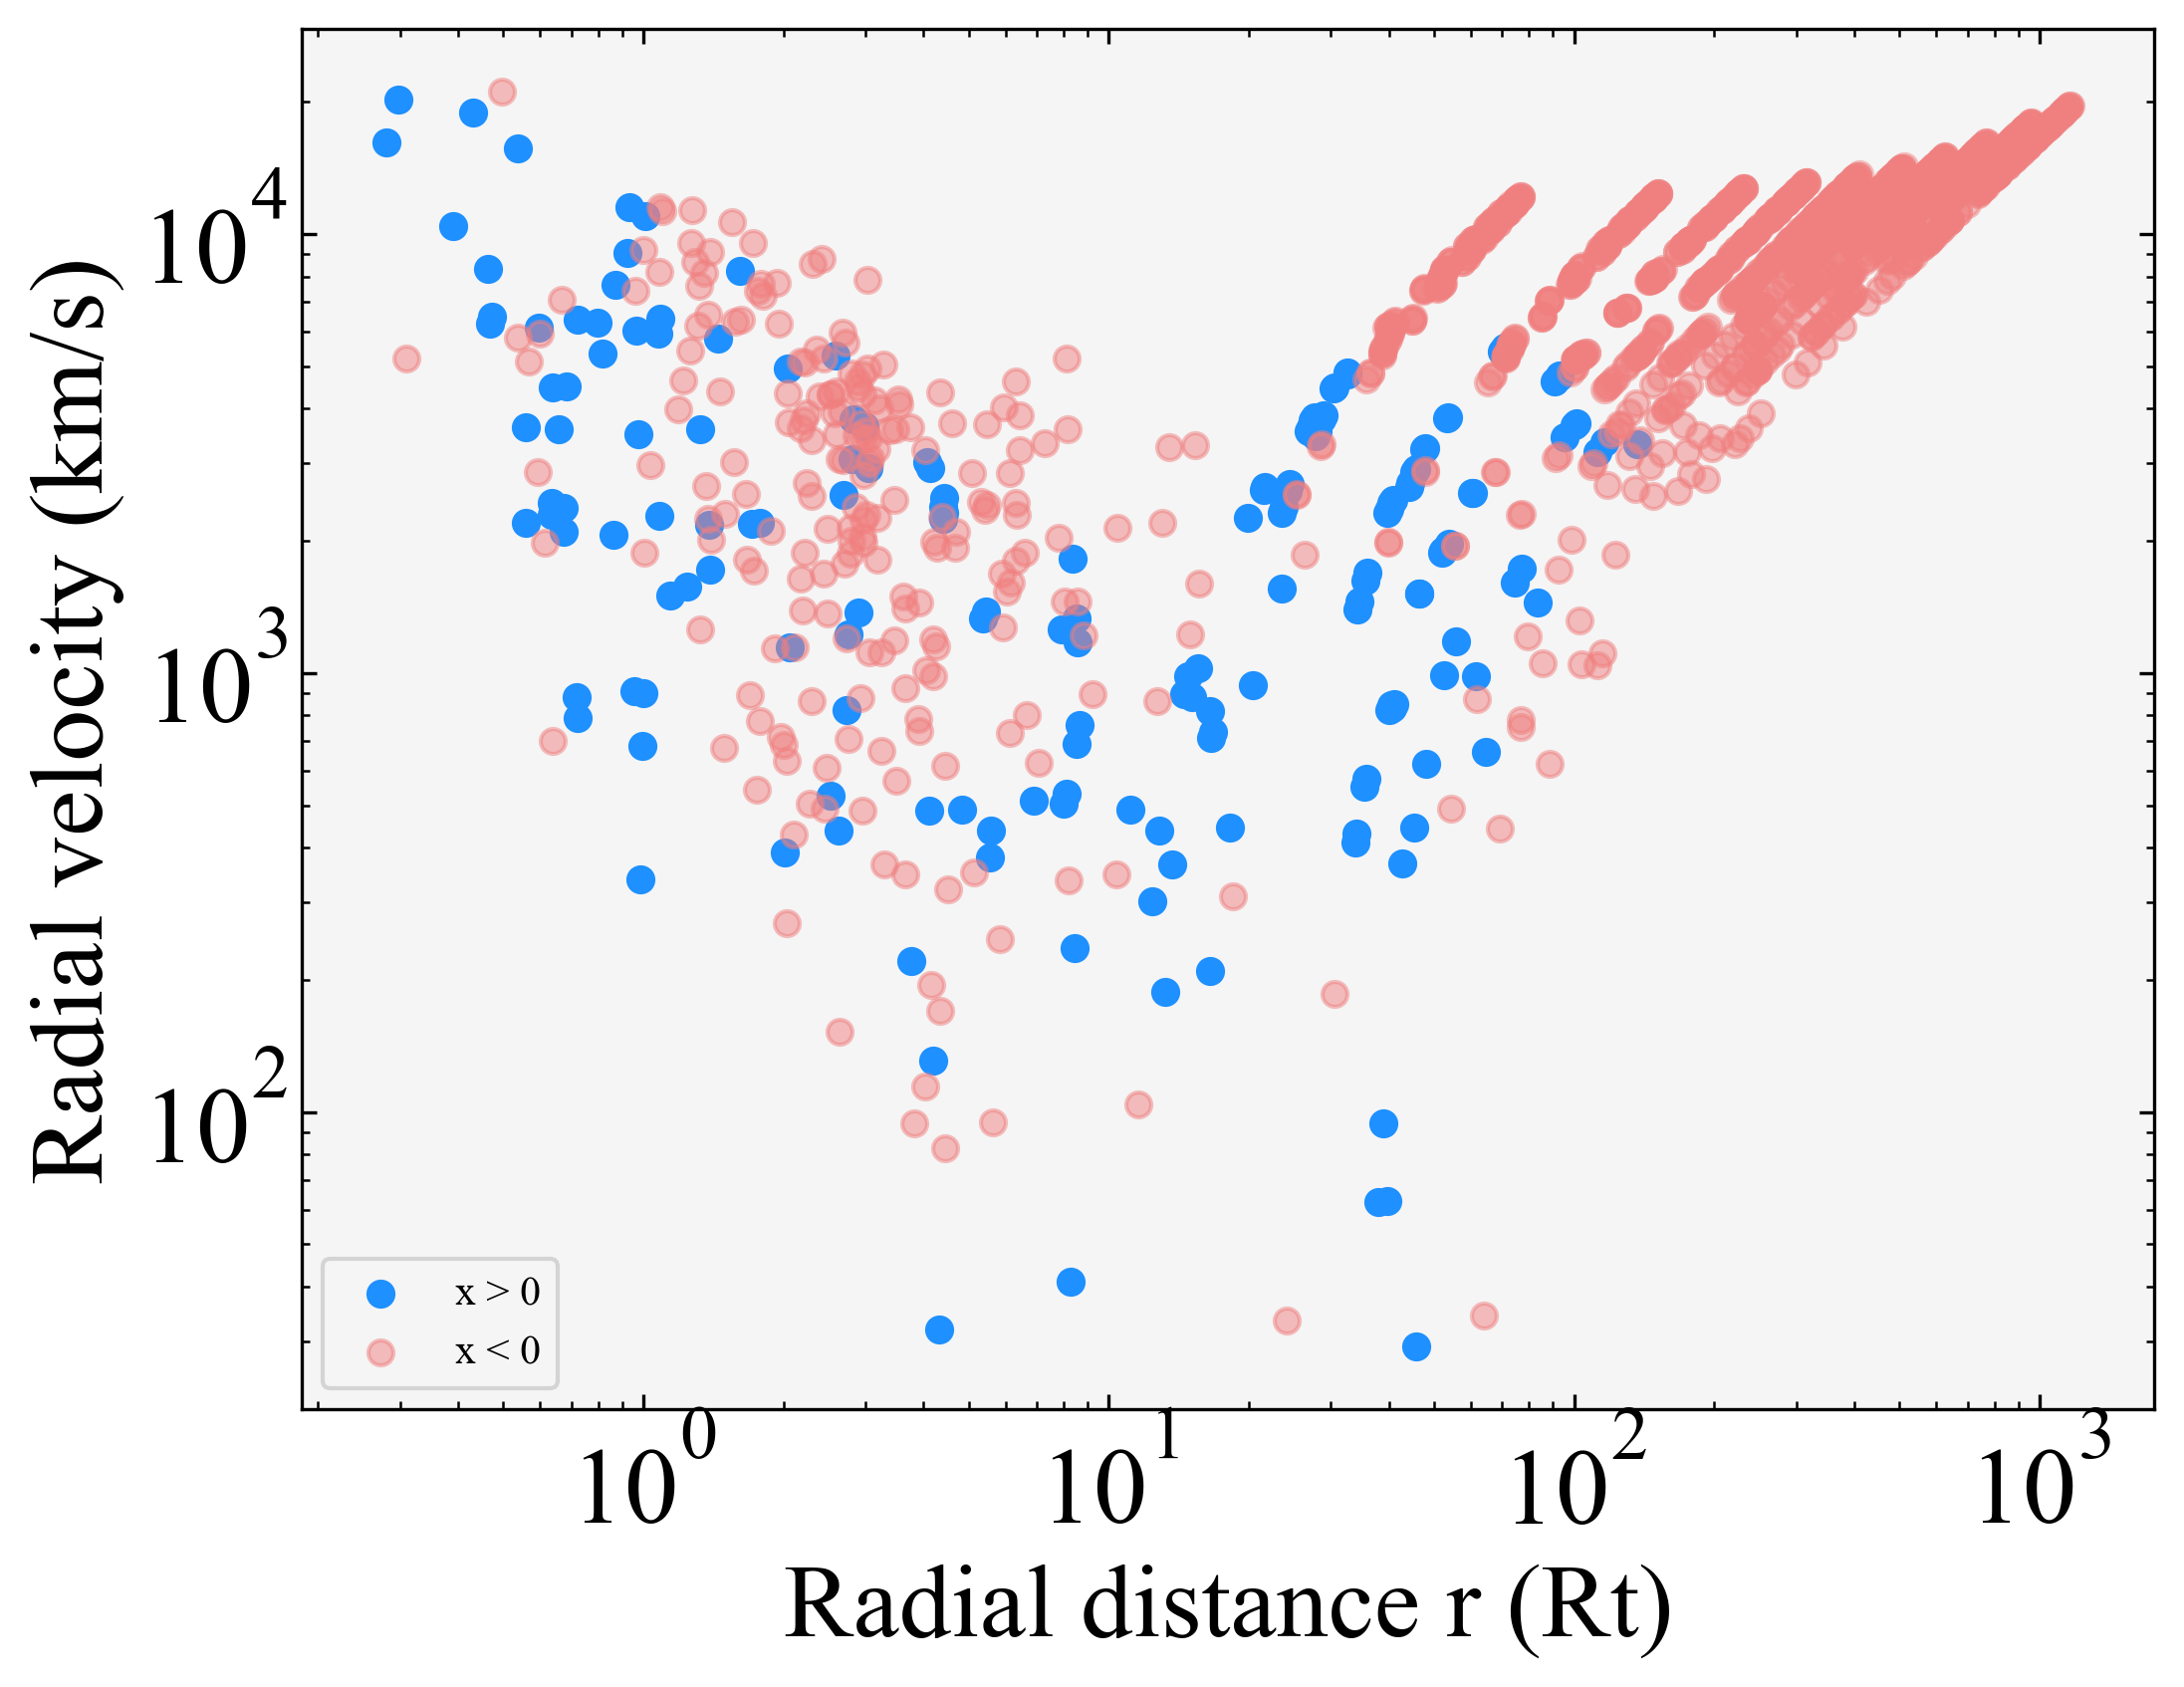

In [ ]:
from Utilities.operators import sort_list
countvRpos, bin_edges = np.histogram(velR_last_pos * conversion_sol_kms, bins=20)
countvRneg, bin_edges = np.histogram(velR_last_neg * conversion_sol_kms, bins=20)
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], countvRpos, width=np.diff(bin_edges), label='x > 0', color='dodgerblue')
plt.bar(bin_edges[:-1], countvRneg, width=np.diff(bin_edges), alpha=0.5, label='x < 0', color='lightcoral')
plt.xlabel('Radial velocity (km/s)')
plt.ylabel('Count of particles')
plt.legend()
plt.loglog()
plt.title(f'Particle distribution at t = {tt[-1]}')

plt.figure(figsize=(8, 6))
velR_last_pos, r_last_pos= sort_list([velR_last_pos, r_last_pos], r_last_pos)
velR_last_neg, r_last_neg= sort_list([velR_last_neg, r_last_neg], r_last_neg)
plt.scatter(r_last_pos, velR_last_pos * conversion_sol_kms, label='x > 0', color='dodgerblue')
plt.scatter(r_last_neg, velR_last_neg * conversion_sol_kms, label='x < 0', color='lightcoral', alpha=0.5)
plt.xlabel('Radial distance r (Rt)')
plt.ylabel('Radial velocity (km/s)')
plt.loglog()
plt.legend()
# plt.xlim(1e2, 2e3)